In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.metrics import ConfusionMatrixDisplay
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
import random

In [2]:
# Set the image dimensions for the input images
IMG_WIDTH, IMG_HEIGHT = 48, 48

# Set the batch size for training and validation
BATCH_SIZE = 32

In [ ]:
# Define the project root based on where this script lives
PROJECT_ROOT = Path.cwd().parent

# Define the paths using the project root
DATA_DIR = PROJECT_ROOT / "data"
train_dir = DATA_DIR / "train"
valid_dir = DATA_DIR / "valid"
test_dir = DATA_DIR / "test"

# Create the train, validation, and test directories if they don't exist
if not (train_dir / 'angry').exists():
    for folder in [train_dir, valid_dir, test_dir]:
        folder.mkdir(exist_ok=True)

    # Move all images to the train directory and create the validation and test directories for each emotion
    for emotion in ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']:
        shutil.move(f'{emotion}', f'train')
        os.makedirs(f'valid/{emotion}')
        os.makedirs(f'test/{emotion}')

        # Move 200 images from each emotion to the validation directory
        valid_samples = random.sample(os.listdir(f'train/{emotion}'), 200)
        for sample in valid_samples:
            shutil.move(f'train/{emotion}/{sample}', f'valid/{emotion}')

        # Move 100 images from each emotion to the test directory
        test_samples = random.sample(os.listdir(f'train/{emotion}'), 100)
        for sample in test_samples:
            shutil.move(f'train/{emotion}/{sample}', f'test/{emotion}')

In [4]:
# Data augmentation for the training process of the model
# It helps to increase the diversity of the training data and improve the model's generalization ability
data_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,            # Rotate up to 20 degrees
    width_shift_range=0.2,        # Shift horizontally
    height_shift_range=0.2,       # Shift vertically
    zoom_range=0.2,               # Zoom in/out
    brightness_range=[0.8, 1.2],  # Change brightness
    horizontal_flip=True          # Flip left-right
)

In [5]:
# Paths for the training, validation, and test datasets
train_path = '/Users/rodrigomolero/Documents/Code/2_Personal/Just_For_Fun/emotion_detection_project/data/train'
valid_path = '/Users/rodrigomolero/Documents/Code/2_Personal/Just_For_Fun/emotion_detection_project/data/valid'
test_path = '/Users/rodrigomolero/Documents/Code/2_Personal/Just_For_Fun/emotion_detection_project/data/test'

In [6]:
# Create the train batch generator
train_batch_generator = data_gen.flow_from_directory(
    directory=train_path, 
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    classes=['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
)

Found 33787 images belonging to 7 classes.


In [7]:
# Create the validation batch generator
valid_batch_generator = data_gen.flow_from_directory(
    directory=valid_path,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    classes=['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
)

Found 1400 images belonging to 7 classes.


In [8]:
# Create the test batch generator
test_batch_generator = data_gen.flow_from_directory(
    directory=test_path,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    classes=['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'],
    shuffle=False
)

Found 700 images belonging to 7 classes.


In [9]:
# Configuring EarlyStopping to stp the training when 'val_loss' stops improving
early_stop = EarlyStopping(
    monitor='val_loss',         # Watch the validation loss
    patience=5,                 # Wait 5 epochs for improvement before stopping
    restore_best_weights=True,  # Roll back to the best version when done
    verbose=1                   # Print a message when training stops
)

In [10]:
# Calculate these by dividing the highest class count (8600 from Neutral) by the count of each class to balance the dataset
class_weights = {
    0: 1.8, # Angry (~4650)
    1: 34.4, # Disgust (~250) <-- High weight!
    2: 1.8, # Fear (~4800)
    3: 1.0, # Happy (~8600)
    4: 1.5, # Neutral (~5900)
    5: 1.5, # Sad (~5700)
    6: 2.3  # Surprise (~3700)
}

In [11]:
model = Sequential([
    # First convolutional block
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(IMG_WIDTH, IMG_HEIGHT, 1)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # Second convolutional block
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # Third convolutional block
    Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # Fourth convolutional block
    Conv2D(filters=256, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),

    # Flatten the output of the convolutional layers
    Flatten(),

    # Fully connected layers
    Dense(units=512, activation='relu'),
    Dropout(rate=0.4),
    Dense(units=256, activation='relu'),
    Dropout(rate=0.4),
    Dense(units=7, activation='softmax')  # 7 classes for emotions
])

# Compile the model with the Adam optimizer and categorical crossentropy loss function
optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

/Users/rodrigomolero/Documents/Code/2_Personal/Just_For_Fun/emotion_detection_project/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# Display the model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,047,687 (4.00 MB)

 Trainable params: 1,046,727 (3.99 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# Train the model using the training and validation batch generators, class weights, and early stopping
model.fit(
    x=train_batch_generator, 
    validation_data=valid_batch_generator, 
    class_weight=class_weights, 
    epochs=100, 
    callbacks=[early_stop]
)

Epoch 1/100
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 45s 41ms/step - accuracy: 0.1718 - loss: 3.8744 - val_accuracy: 0.1929 - val_loss: 1.9246
Epoch 2/100
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 44s 42ms/step - accuracy: 0.1694 - loss: 3.5630 - val_accuracy: 0.2057 - val_loss: 1.9127
Epoch 3/100
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step - accuracy: 0.1801 - loss: 3.4693 - val_accuracy: 0.2150 - val_loss: 1.9014
Epoch 4/100
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 48s 45ms/step - accuracy: 0.1888 - loss: 3.4362 - val_accuracy: 0.2193 - val_loss: 1.9043
Epoch 5/100
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step - accuracy: 0.1985 - loss: 3.3940 - val_accuracy: 0.2371 - val_loss: 1.8777
Epoch 6/100
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 46s 44ms/step - accuracy: 0.2050 - loss: 3.3560 - val_accuracy: 0.2407 - val_loss: 1.8640
Epoch 7/100
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 47s 44ms/step - accuracy: 0.2207 - loss: 3.3220 - val_accuracy: 0.2629 - val_loss: 1.8345
Epoch 8/100
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 47s 44ms/step - accuracy: 

In [ ]:
# Display the true labels of the test dataset for evaluation purposes
test_labels = test_batch_generator.classes
print(test_labels)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 4 4 4 

In [ ]:
# Make predictions on the test dataset using the trained model
predictions = model.predict(x=test_batch_generator)
# Display the predicted class labels for the test dataset
print(predictions.argmax(axis=1))

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
[[5.0840598e-02 1.9783042e-04 1.8722838e-01 ... 1.4736996e-02
  2.2844160e-02 7.2292286e-01]
 [1.6247821e-01 2.9747772e-01 1.5837607e-01 ... 7.4724860e-02
  1.0068307e-01 9.2725068e-02]
 [4.9547541e-01 1.7907226e-01 2.4982977e-01 ... 7.6651131e-03
  4.1582920e-02 1.8286610e-02]
 ...
 [2.4035713e-03 4.2352701e-07 1.2289785e-01 ... 1.0086028e-03
  1.3344262e-03 8.7165481e-01]
 [4.3157055e-03 3.4463974e-05 9.3205079e-02 ... 1.3509557e-03
  1.0507742e-03 8.9900416e-01]
 [2.5434340e-03 3.6423330e-08 3.7512876e-02 ... 1.1246060e-02
  9.4758678e-04 9.4751912e-01]]
[6 1 0 0 0 0 6 0 4 1 1 4 1 4 1 0 0 5 5 1 1 0 5 5 4 5 4 3 1 0 0 4 5 3 4 0 1
 3 4 4 4 0 4 4 0 5 3 0 6 2 6 1 3 1 4 5 1 6 0 4 5 1 5 0 1 1 1 0 0 5 0 0 1 0
 5 0 4 0 1 1 0 1 5 3 5 3 1 3 0 4 2 1 1 0 2 6 4 0 0 0 1 1 1 1 1 4 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 0 1 2 5 1 1 1 0 1 0 5 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2
 1 1 1 1 1 1 1 1 1 5 5 0 0 0 5 1 1 0 1 1 1 3 5 0 1 5 0 1 3 1 1 0 5 5 0 1 5
 1 1 1 1 1 1 1 1 1 1 

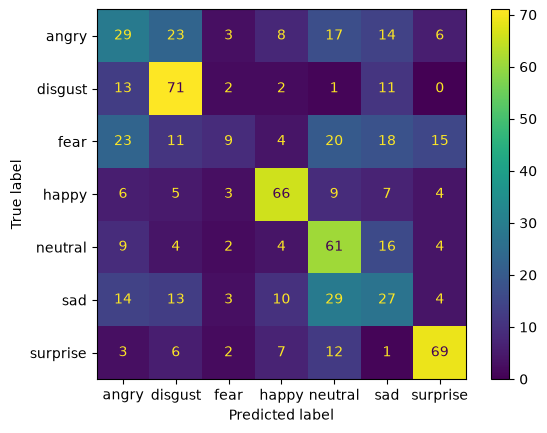

In [ ]:
# Display the confusion matrix using the true test labels and the predicted ones from our model
y_true = test_labels
y_pred = predictions.argmax(axis=1)
cm_plot_labels = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=cm_plot_labels)
plt.show()

In [ ]:
# Save the trained model
model.save('models/emotion_model.keras')